In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from dotenv import load_dotenv

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import sys
sys.path.insert(0, '../..')

from nn.dataset import CarPriceDataset
from nn.model import MLPCarPriceRegressionNet_V1
from nn.model_functions import train_model, plot_training 
from nn.model_functions import test_model, plot_test, plot_outlier_years, plot_outlier_km

from preprocessing.preprocess import PreProcessor
from preprocessing.clean import Cleaner
from preprocessing.impute import Imputer
from preprocessing.engineer import Engineer 


In [2]:
df = pd.read_csv('../../data/raw/car_details.csv')

cleaner = Cleaner()
imputer = Imputer()
engineer = Engineer()

df = cleaner.clean(df)
summary = cleaner.get_summary()
display(summary)

df = imputer.impute(df)
summary = imputer.get_summary()
display(summary)

df = engineer.transform(df)
summary = engineer.get_summary()
display(summary)


,Feature,Length Before,Length After,Dropped
0,Price,106447,104697,1750
1,Year,104697,100474,4223
2,Manufacturer/Model,100474,100326,148
3,Kilometers,100326,100304,22
4,Fuel Type,100304,100304,0
5,KW/LE,100304,98966,1338
6,Condition,98966,98966,0
7,Trunk Capacity,98966,98959,7
8,Body Type,98959,98956,3
9,Seats,98956,98951,5


,Feature,Missing Before,Missing After,Imputed
0,Kilometers,1676,0,1676
1,Fuel Type,706,0,706
2,Trunk Capacity,10189,0,10189
3,Seats,1249,0,1249
4,Color,21573,0,21573
5,Engine Capacity,392,0,392
6,Drive Type,2261,0,2261
7,Transmission Type,3881,0,3881
8,Number of Gears,18107,0,18107


,Feature,Unqiue Before,Unqiue After
0,Fuel Type,14,7
1,Transmission Type,10,6
2,Color,76,38


In [3]:
df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

preprocessor = PreProcessor()
preprocessor.fit(df_train)
preprocessor.save('../../config/preprocessor_config.pkl', '../../config/preprocessor_config.json')

model = MLPCarPriceRegressionNet_V1('../../config/preprocessor_config.pkl')

X_num_train, X_cat_train, y_train = preprocessor.transform(df_train, is_training = True, include_target = True)
X_num_val, X_cat_val, y_val = preprocessor.transform(df_val, is_training = False, include_target = True)
X_num_test, X_cat_test, y_test = preprocessor.transform(df_test, is_training = False, include_target = True)

train_dataset = CarPriceDataset(X_num_train, X_cat_train, y_train)
val_dataset = CarPriceDataset(X_num_val, X_cat_val, y_val)
test_dataset = CarPriceDataset(X_num_test, X_cat_test, y_test)

dataloader_train = DataLoader(dataset = train_dataset, batch_size = 64, shuffle = True)
dataloader_val = DataLoader(dataset = val_dataset, batch_size = 64, shuffle = True)
dataloader_test = DataLoader(dataset = test_dataset, batch_size = 64, shuffle = False)

In [4]:
'''
history, model = train_model(
    model=model,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    epochs=150,
    learning_rate=0.0005
)
plot_training(history=history)
torch.save(model.state_dict(), '../../models/basic_model.pt')
'''

"\nhistory, model = train_model(\n    model=model,\n    train_loader=dataloader_train,\n    val_loader=dataloader_val,\n    epochs=150,\n    learning_rate=0.0005\n)\nplot_training(history=history)\ntorch.save(model.state_dict(), '../../models/basic_model.pt')\n"


MODEL TEST RESULTS
Test set size: 9,894 cars

Error Metrics:
  MAE:  1.18M Ft
  RMSE: 2.74M Ft
  MAPE: 17.10%
  Median APE: 12.73%

Accuracy:
  Within 10%: 40.4%
  Within 20%: 71.2%
  Within 30%: 86.8%

Prediction Bias:
  Mean error: -834766.81 Ft
  Overpredictions: 30.0%
  Underpredictions: 70.0%


TypeError: float() argument must be a string or a real number, not 'builtin_function_or_method'

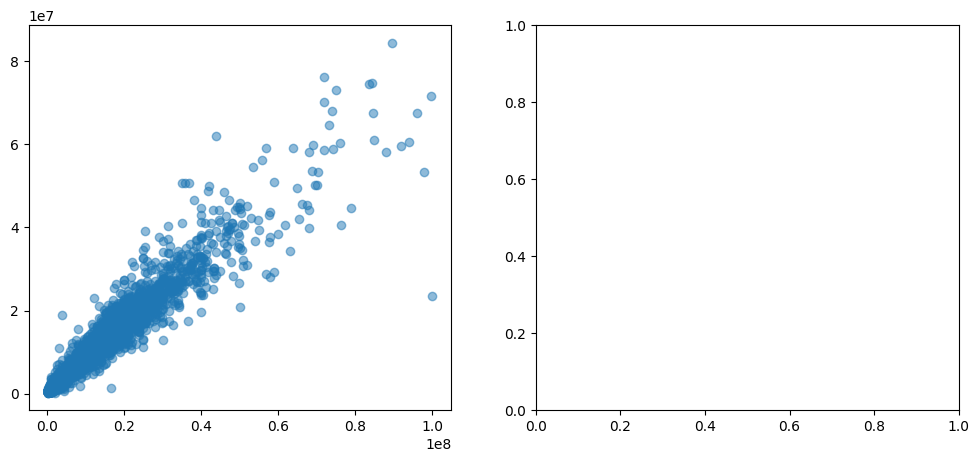

In [5]:
model.load_state_dict(torch.load('../../models/basic_model.pt'))

prediction_prices, actual_prices, _ , percent_errors, metrics = test_model(model, dataloader_test)
plot_test(actual_prices, prediction_prices, percent_errors, metrics['mape'])

#plot_outlier_years(model, dataloader_test, df_test, threshold=50)
#plot_outlier_km(model, dataloader_test, df_test, threshold=50)